Utilizando 02_teste_lane_sobel nas imagens

In [2]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

caminho_atual = Path.cwd()
if caminho_atual.name == "notebooks":
    raiz_projeto = caminho_atual.parent
else:
    raiz_projeto = caminho_atual
pasta_imagens = raiz_projeto / "imagens"
print("Pasta das imagens:", pasta_imagens)

IMAGE_SIZE = (512, 512)
GAUSSIAN_BLUR_KERNEL = (5, 5)
SOBEL_KSIZE = 3

Pasta das imagens: c:\Users\Maria Clara\processamento-de-imagens\imagens


In [3]:
def carregar_e_redimensionar(caminho, modo=cv2.IMREAD_COLOR, tamanho=IMAGE_SIZE):
    img = cv2.imread(str(caminho), modo)
    if img is None:
        raise ValueError(f"Erro ao carregar: {caminho}")
    return cv2.resize(img, tamanho)

def localizar_arquivo(pasta, tipo):
    arquivos = list(pasta.glob(f"*_{tipo}.*"))
    if not arquivos:
        raise FileNotFoundError(f"{tipo} não encontrado em {pasta}")
    return arquivos[0]

def carregar_mascara(caminho, tamanho=IMAGE_SIZE):
    mascara = cv2.imread(str(caminho), cv2.IMREAD_GRAYSCALE)
    if mascara is None:
        raise ValueError(f"Erro ao carregar máscara: {caminho}")
    return cv2.resize(mascara, tamanho)

def aplicar_mascara(imagem, mascara):
    return cv2.bitwise_and(imagem, imagem, mask=mascara)

def preprocessar(imagem_pista):
    cinza = cv2.cvtColor(imagem_pista, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(cinza, GAUSSIAN_BLUR_KERNEL, 0)
    equalizada = cv2.equalizeHist(blur)
    return cinza, blur, equalizada

def aplicar_sobel(equalizada):
    sobel_x = cv2.Sobel(equalizada, cv2.CV_64F, 1, 0, ksize=SOBEL_KSIZE)
    sobel_y = cv2.Sobel(equalizada, cv2.CV_64F, 0, 1, ksize=SOBEL_KSIZE)
    magnitude = cv2.magnitude(sobel_x, sobel_y)
    sobel = cv2.convertScaleAbs(magnitude)
    return sobel

In [4]:
casos = sorted([pasta for pasta in pasta_imagens.iterdir() if pasta.is_dir()], key=lambda x: int(x.name.split("_")[1]))
print("Quantidade de imagens:", len(casos))
for caso in casos:
    print(caso.name)

Quantidade de imagens: 10
img_161
img_1346
img_1460
img_1790
img_2056
img_2076
img_2099
img_2100
img_2116
img_2130



Processando: img_161


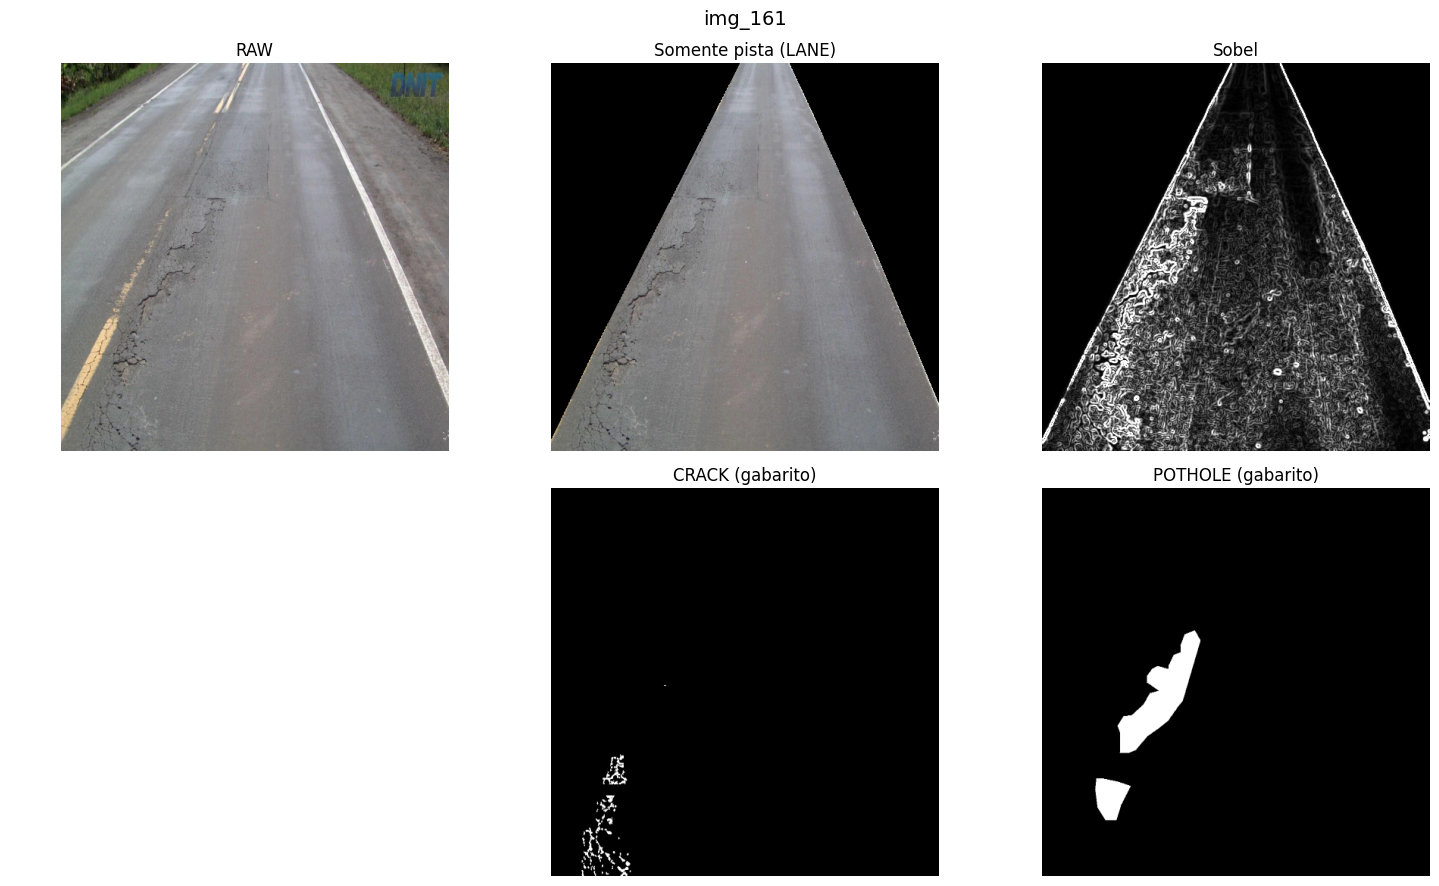


Processando: img_1346


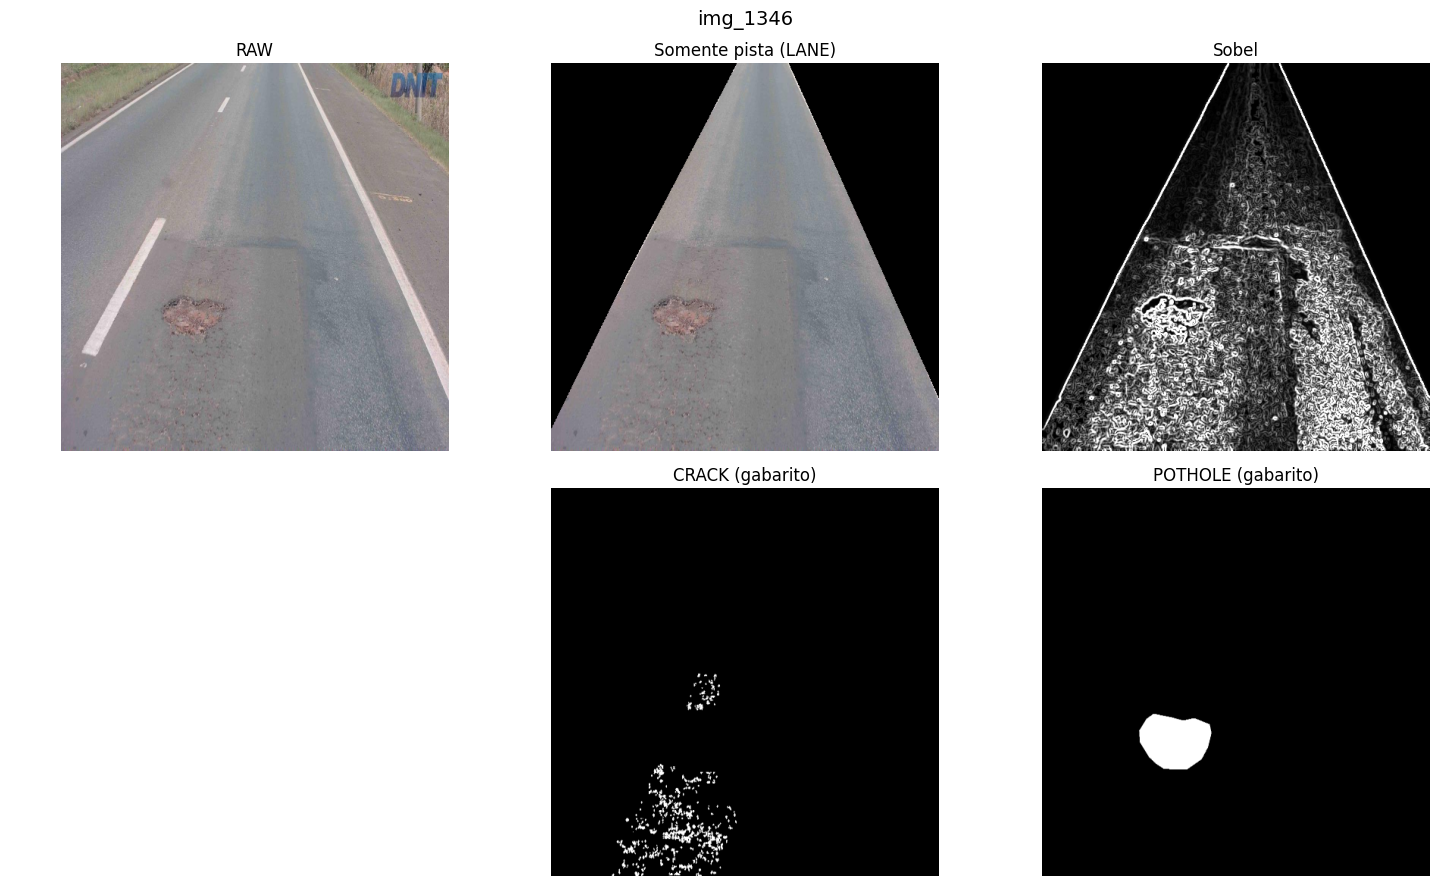


Processando: img_1460


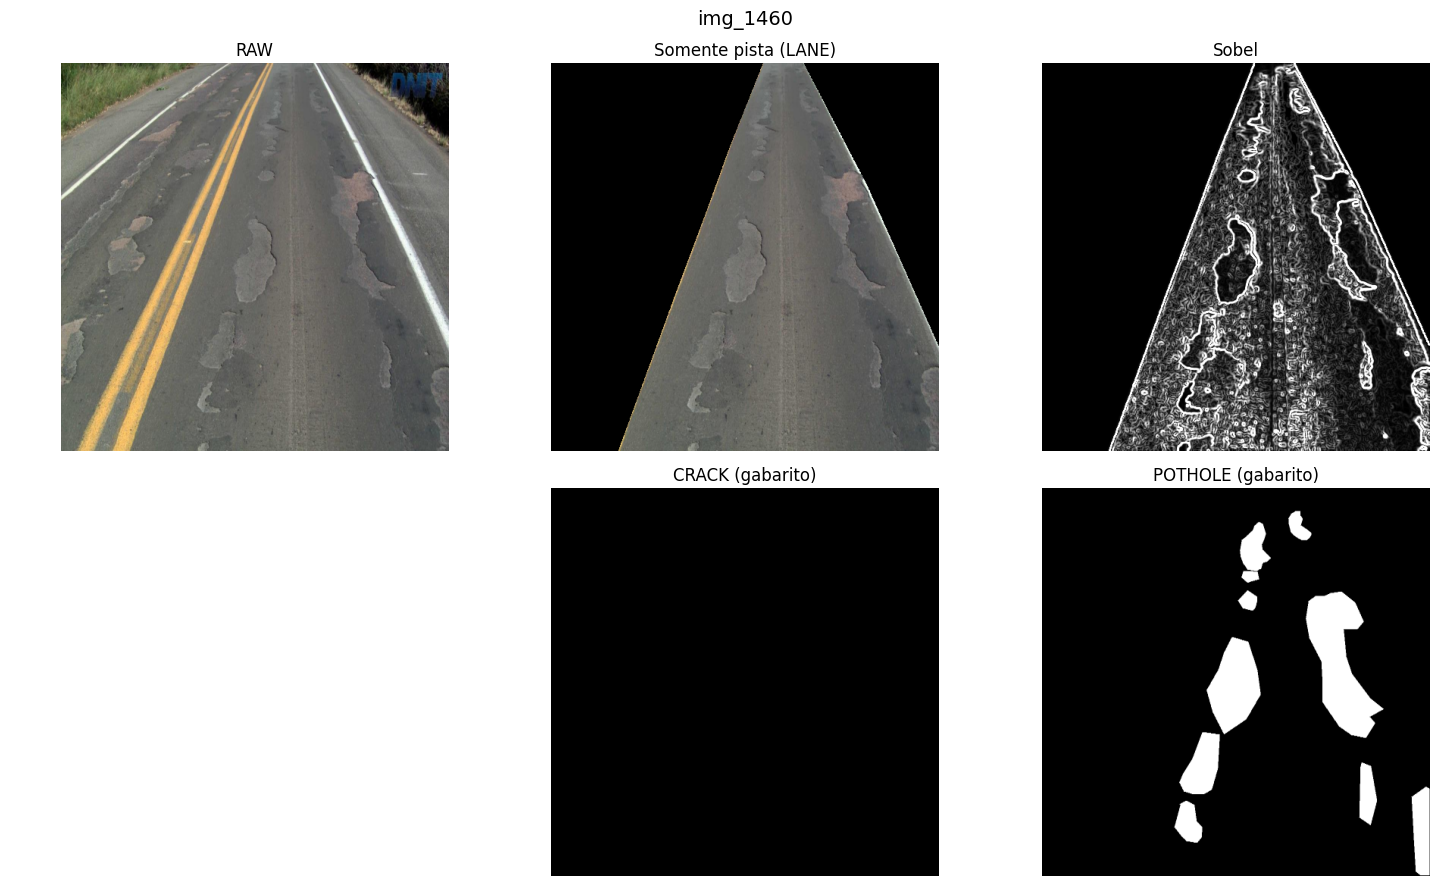


Processando: img_1790


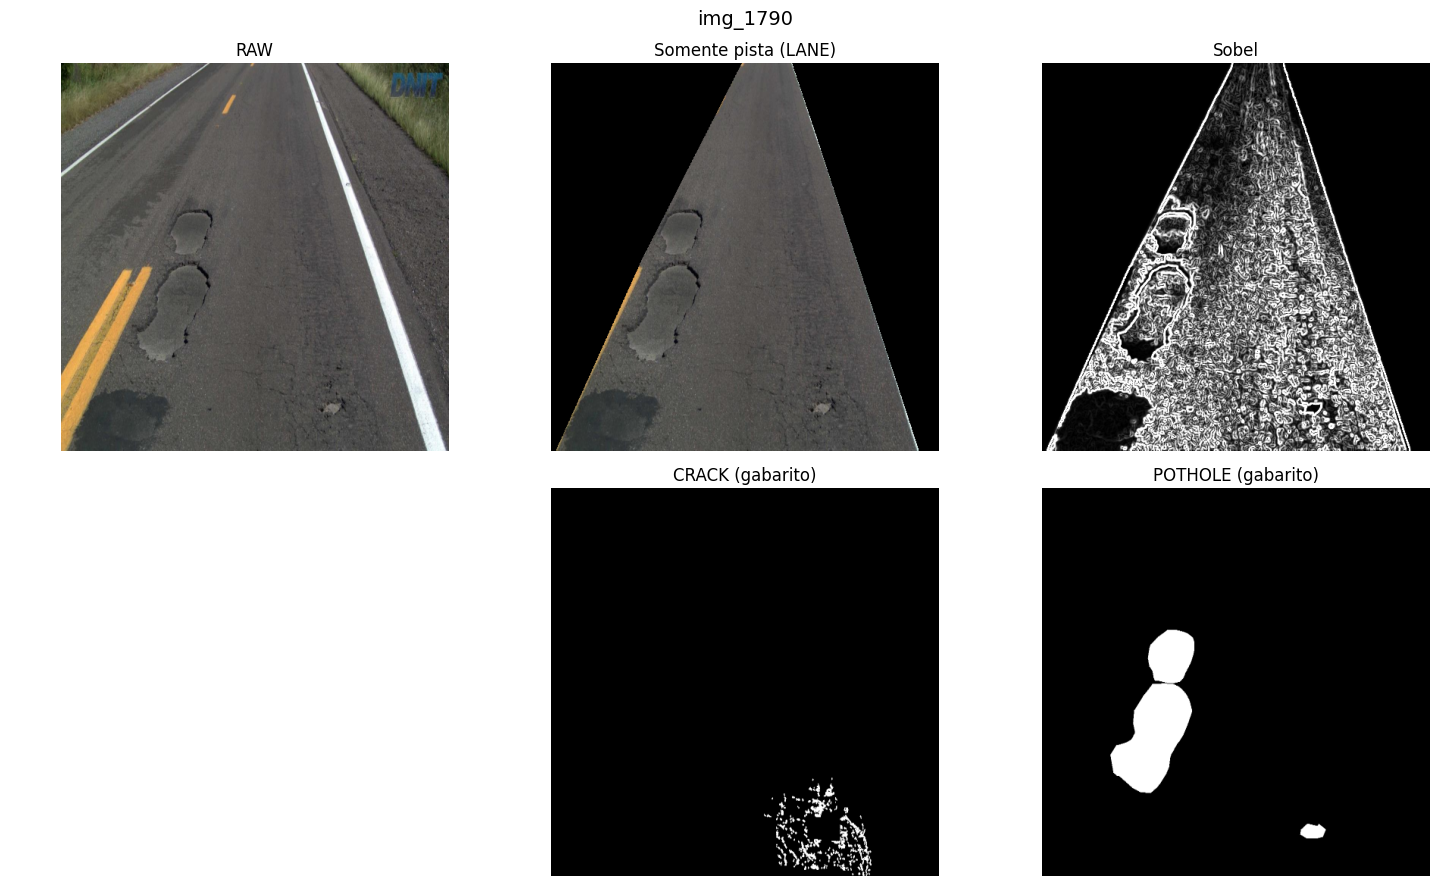


Processando: img_2056


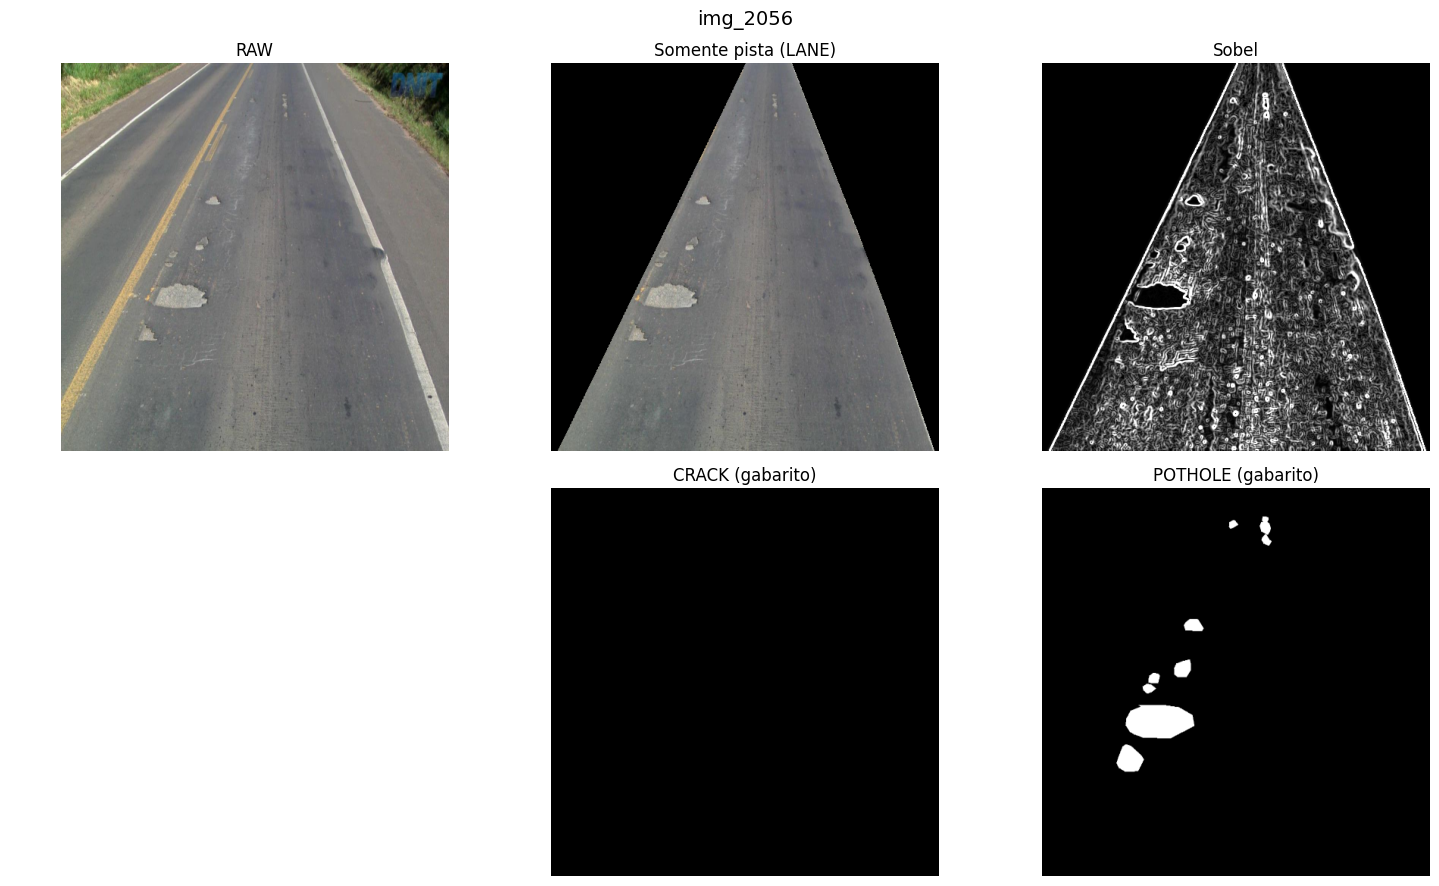


Processando: img_2076


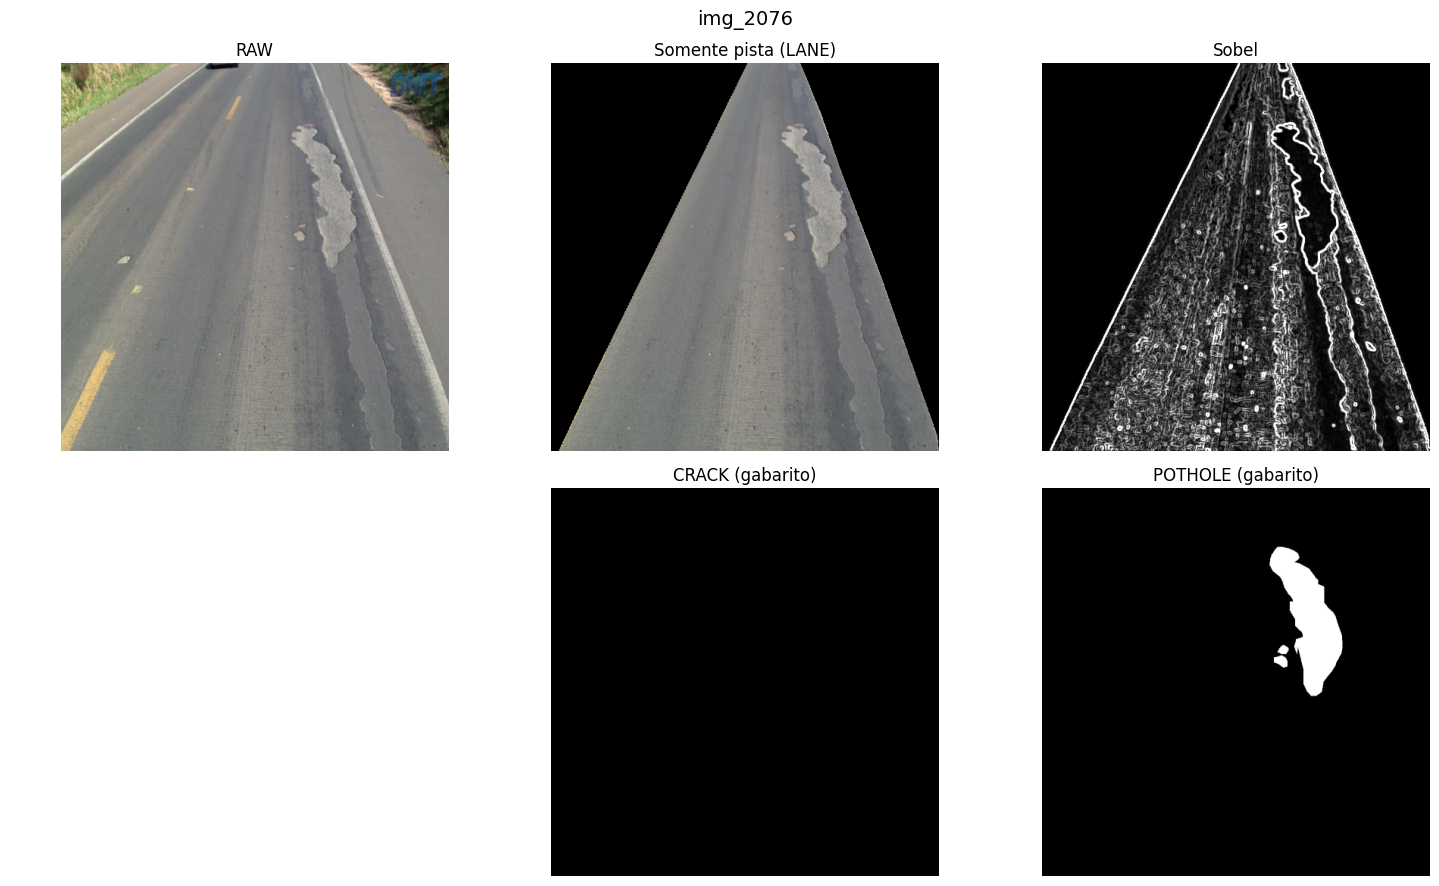


Processando: img_2099


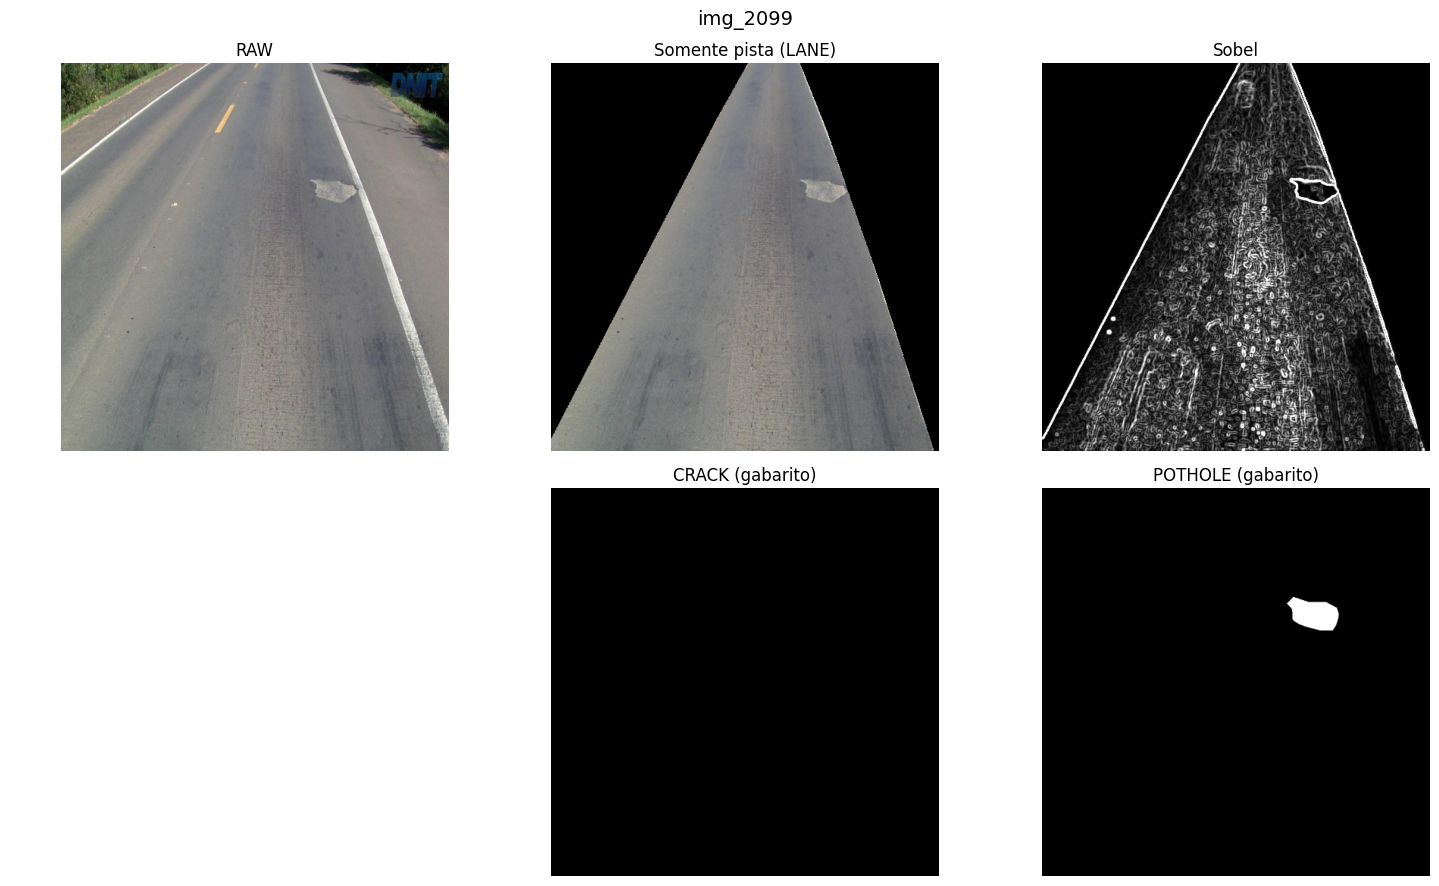


Processando: img_2100


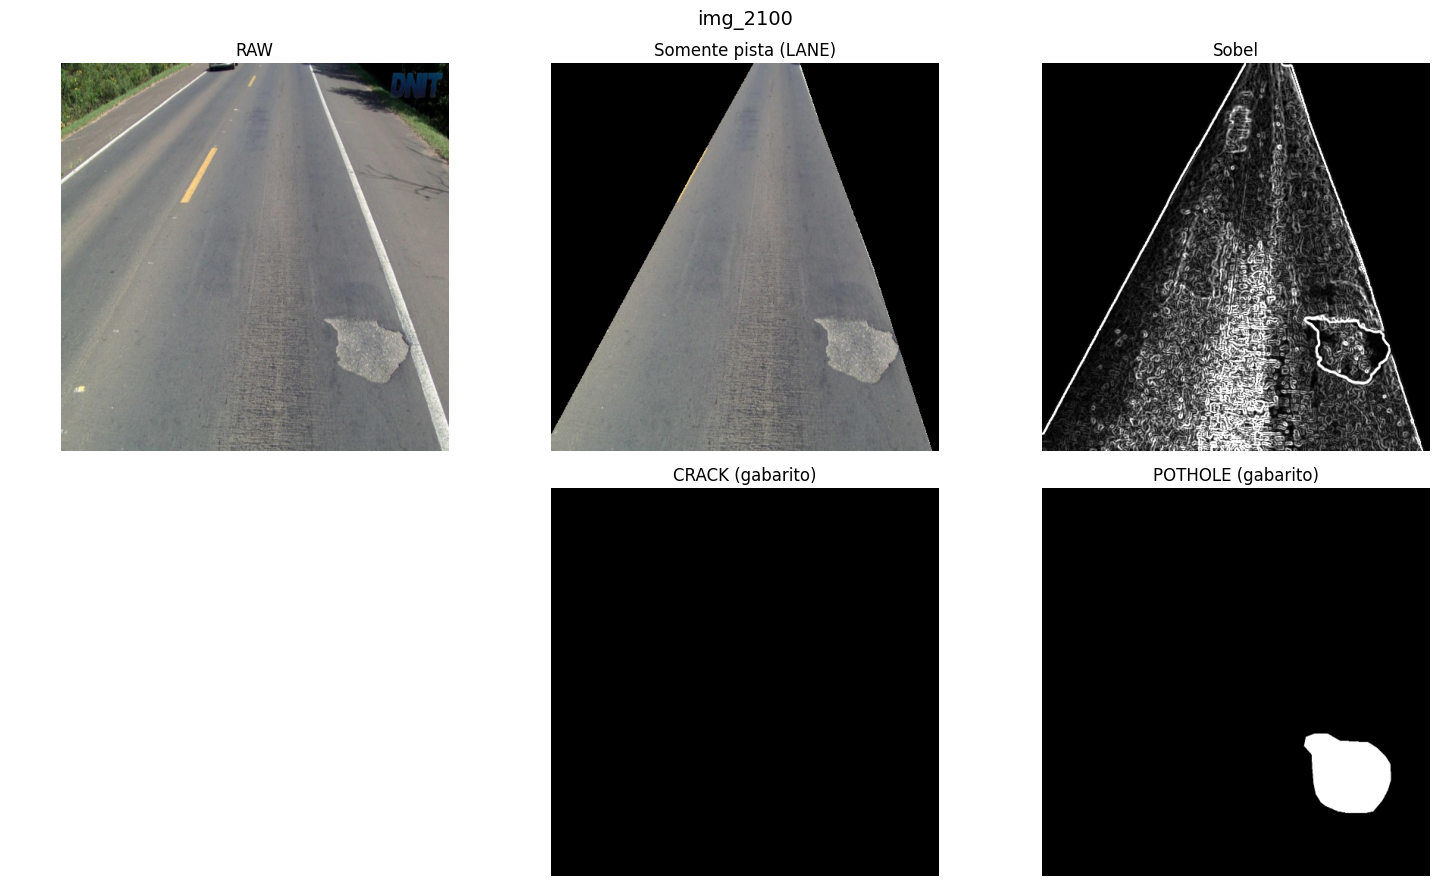


Processando: img_2116


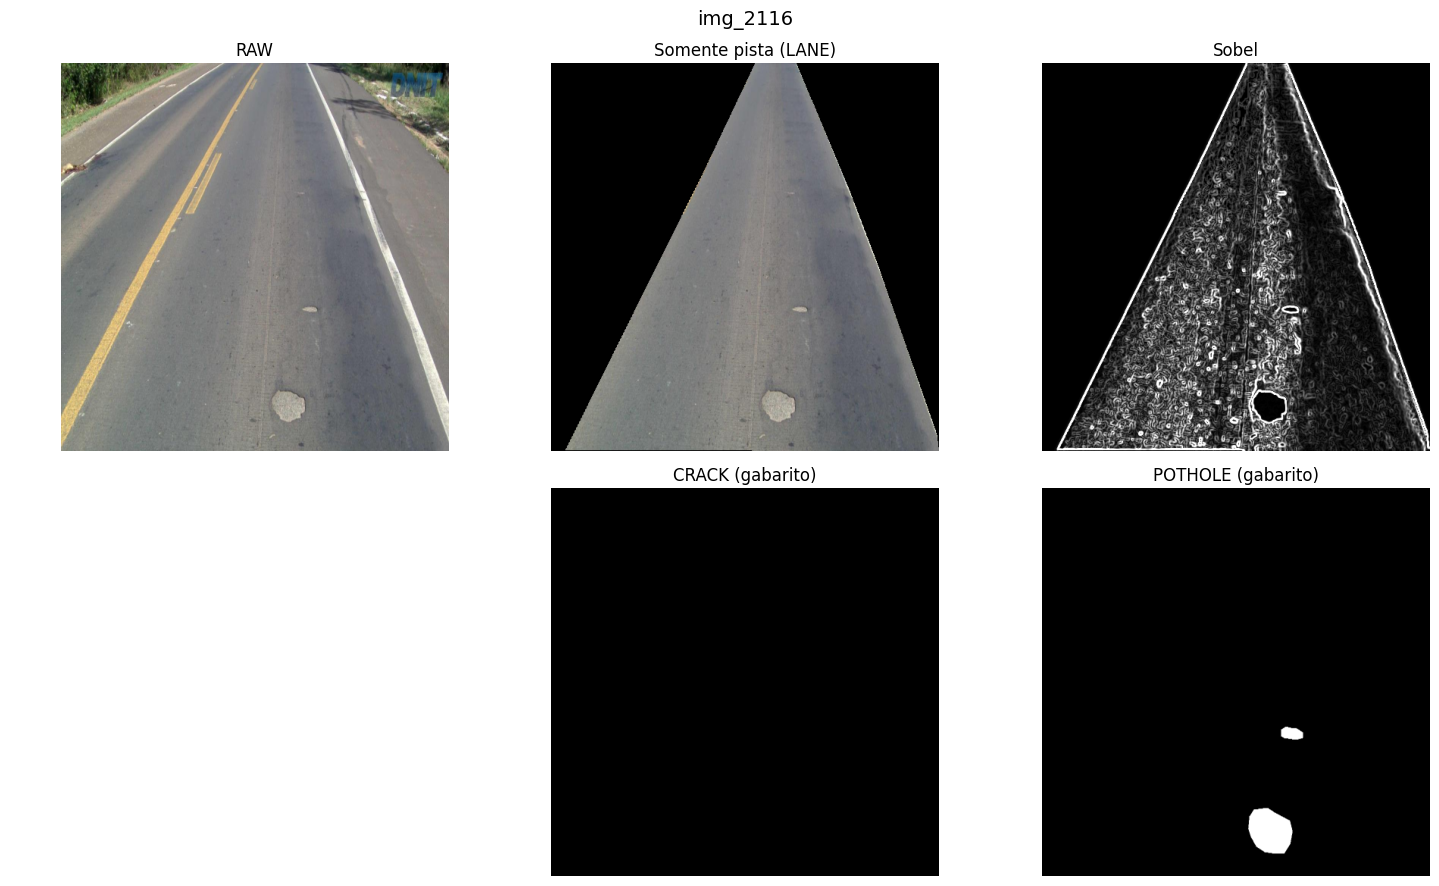


Processando: img_2130


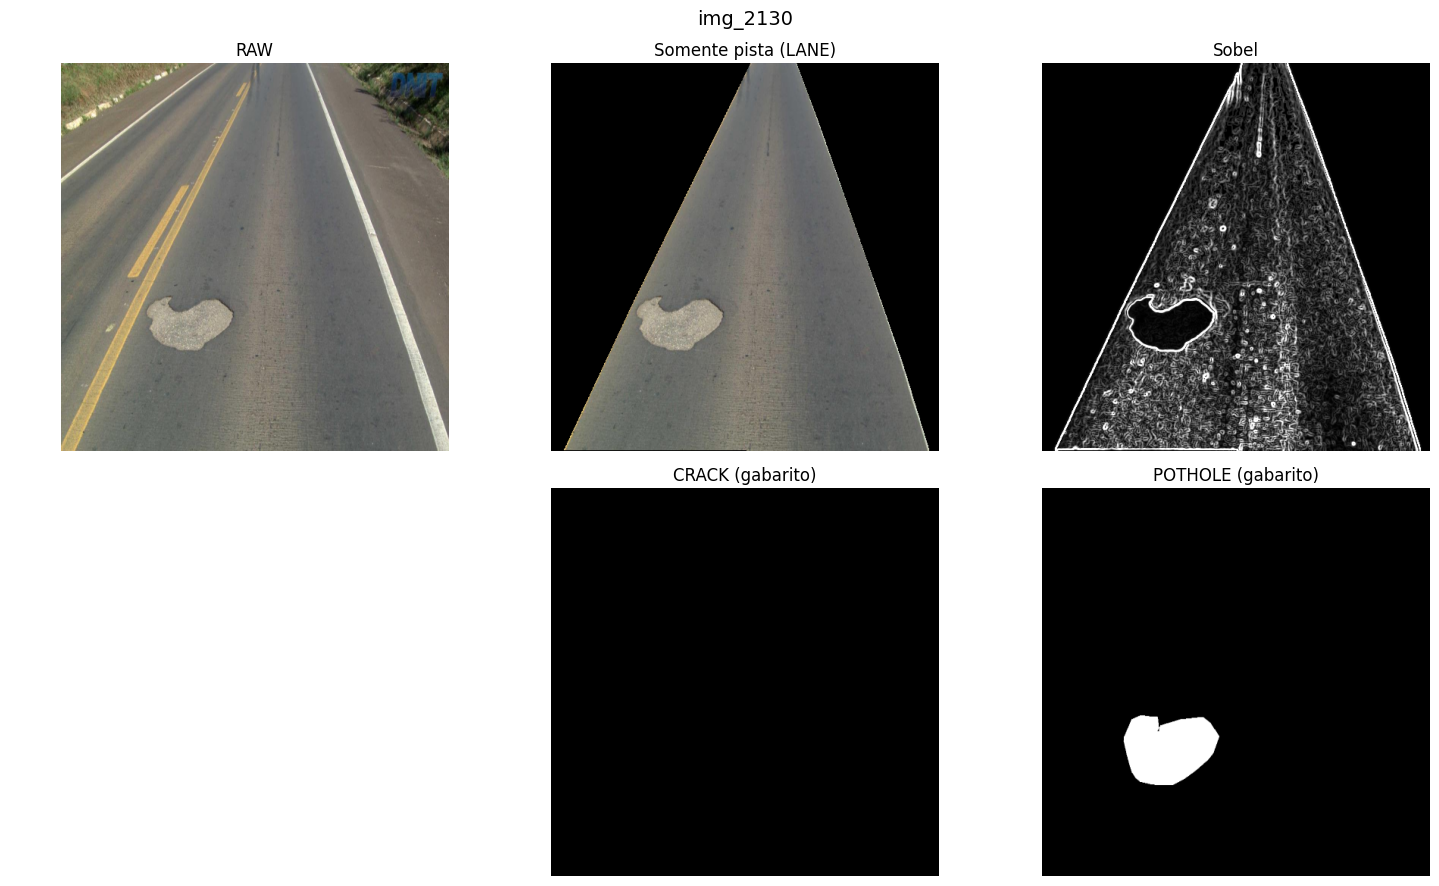

In [5]:
for caso in casos:
    print("\nProcessando:", caso.name)
    caminho_raw = localizar_arquivo(caso, "RAW")
    caminho_lane = localizar_arquivo(caso, "LANE")
    caminho_crack = localizar_arquivo(caso, "CRACK")
    caminho_pothole = localizar_arquivo(caso, "POTHOLE")

    imagem = carregar_e_redimensionar(caminho_raw)
    lane = carregar_e_redimensionar(caminho_lane, cv2.IMREAD_GRAYSCALE)
    crack = carregar_mascara(caminho_crack)
    pothole = carregar_mascara(caminho_pothole)

    imagem_pista = aplicar_mascara(imagem, lane)

    cinza, blur, equalizada = preprocessar(imagem_pista)

    sobel = aplicar_sobel(equalizada)

    plt.figure(figsize=(15,9))
    plt.subplot(2,3,1)
    plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))
    plt.title("RAW")
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.imshow(cv2.cvtColor(imagem_pista, cv2.COLOR_BGR2RGB))
    plt.title("Somente pista (LANE)")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(sobel, cmap="gray")
    plt.title("Sobel")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.imshow(crack, cmap="gray")
    plt.title("CRACK (gabarito)")
    plt.axis("off")

    plt.subplot(2,3,6)
    plt.imshow(pothole, cmap="gray")
    plt.title("POTHOLE (gabarito)")
    plt.axis("off")

    plt.suptitle(caso.name, fontsize=14)
    plt.tight_layout()
    plt.show()